In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


In [23]:
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [24]:
df.shape

(1470, 35)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [26]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


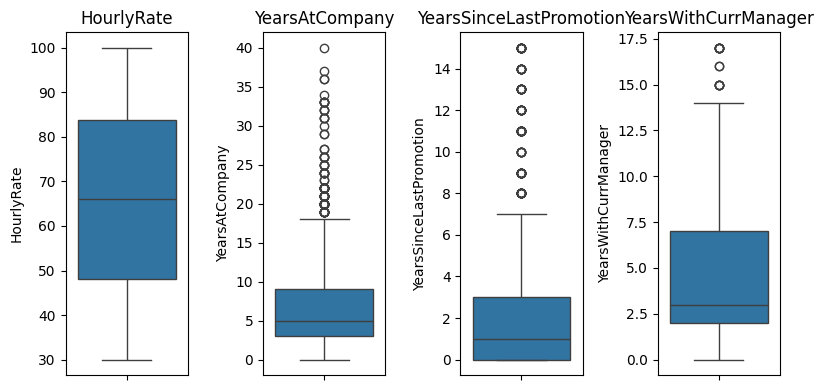

In [27]:
num_cols = ['HourlyRate','YearsAtCompany','YearsSinceLastPromotion','YearsWithCurrManager']

fig, axes = plt.subplots(1,4, figsize=(8,4))
for ax, col in zip(axes,num_cols):
  sns.boxplot(y=df[col],ax=ax)
  ax.set_title(col)
  plt.tight_layout()
plt.show()

In [28]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower:.2f} - {upper:.2f})")


HourlyRate: 0 outliers (bounds: -5.62 - 137.38)
YearsAtCompany: 104 outliers (bounds: -6.00 - 18.00)
YearsSinceLastPromotion: 107 outliers (bounds: -4.50 - 7.50)
YearsWithCurrManager: 14 outliers (bounds: -5.50 - 14.50)


In [29]:
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']
df = df.drop(columns=cols_to_drop)
print(df.shape)
print(df.columns.tolist())

(1470, 31)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [30]:
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'], drop_first=True)

In [31]:
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])
le_overtime = LabelEncoder()
df['OverTime'] = le_overtime.fit_transform(df['OverTime'])

In [32]:
x = df.drop('Attrition', axis=1)
y = df['Attrition'].map({'No': 0, 'Yes': 1})


In [33]:
print(x.select_dtypes(include='object').columns.tolist())
print(y.unique())

[]
[1 0]


In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {x_train.shape, y_train.shape}")
print(f"Test set: {x_test.shape, y_test.shape}")


Train set: ((1176, 44), (1176,))
Test set: ((294, 44), (294,))


In [35]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [36]:
baseline_model = LogisticRegression(max_iter=2000, random_state=42)
baseline_model.fit(x_train_scaled, y_train)
y_pred_baseline = baseline_model.predict(x_test_scaled)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))


Baseline Accuracy: 0.8605442176870748


In [37]:
balanced_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
balanced_model.fit(x_train_scaled, y_train)

y_pred_balanced = balanced_model.predict(x_test_scaled)

print("Balanced Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Balanced Accuracy: 0.7517006802721088
[[192  55]
 [ 18  29]]
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [38]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search_balanced = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search_balanced.fit(x_train_scaled, y_train)

print("Best Parameters:", grid_search_balanced.best_params_)
print("Best F1 Score:", grid_search_balanced.best_score_)

best_balanced_model = grid_search_balanced.best_estimator_
y_pred_best_balanced = best_balanced_model.predict(x_test_scaled)

print(confusion_matrix(y_test, y_pred_best_balanced))
print(classification_report(y_test, y_pred_best_balanced))

Best Parameters: {'C': 1}
Best F1 Score: 0.5097344357716415
[[192  55]
 [ 18  29]]
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [39]:
best_balanced_model.fit(x_train_scaled, y_train)
y_pred_best_balanced = best_balanced_model.predict(x_test_scaled)

In [40]:
rf_model2 = RandomForestClassifier(n_estimators=200, class_weight='balanced_subsample', random_state=42)
rf_model2.fit(x_train, y_train)

y_pred_rf2 = rf_model2.predict(x_test)

print("RF2 Accuracy:", accuracy_score(y_test, y_pred_rf2))
print(confusion_matrix(y_test, y_pred_rf2))
print(classification_report(y_test, y_pred_rf2))

RF2 Accuracy: 0.8367346938775511
[[243   4]
 [ 44   3]]
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.43      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.64      0.52      0.51       294
weighted avg       0.78      0.84      0.78       294



In [41]:
y_proba_rf = rf_model2.predict_proba(x_test)[:, 1]

for t in [0.2]:
    y_pred_t = (y_proba_rf >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_t))


Threshold = 0.2
              precision    recall  f1-score   support

           0       0.92      0.82      0.87       247
           1       0.41      0.64      0.50        47

    accuracy                           0.79       294
   macro avg       0.66      0.73      0.68       294
weighted avg       0.84      0.79      0.81       294



In [42]:
y_proba_rf = rf_model2.predict_proba(x_test)[:, 1]

results = x_test.copy()
results['Attrition_Risk_Score'] = y_proba_rf
results['Actual'] = y_test.values

results_sorted = results.sort_values('Attrition_Risk_Score', ascending=False)
print(results_sorted[['Attrition_Risk_Score', 'Actual']].head(15))

      Attrition_Risk_Score  Actual
911                  0.760       1
688                  0.760       1
301                  0.690       0
711                  0.625       1
1061                 0.605       0
109                  0.570       0
17                   0.515       0
764                  0.500       0
357                  0.495       1
762                  0.485       1
41                   0.480       0
476                  0.455       0
1402                 0.450       0
670                  0.440       0
1311                 0.440       0


In [43]:
def risk_category(score):
    if score >= 0.6:
        return 'High Risk'
    elif score >= 0.3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

results_sorted['Risk_Category'] = results_sorted['Attrition_Risk_Score'].apply(risk_category)
print(results_sorted['Risk_Category'].value_counts())

Risk_Category
Low Risk       255
Medium Risk     34
High Risk        5
Name: count, dtype: int64


In [44]:
importances = rf_model2.feature_importances_
feature_names = x_train.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feat_importance_df.head(15))

                 Feature  Importance
10         MonthlyIncome    0.075781
18     TotalWorkingYears    0.059078
0                    Age    0.058664
1              DailyRate    0.049478
11           MonthlyRate    0.045794
21        YearsAtCompany    0.044787
6             HourlyRate    0.044542
2       DistanceFromHome    0.044480
24  YearsWithCurrManager    0.041524
13              OverTime    0.040730
12    NumCompaniesWorked    0.038500
17      StockOptionLevel    0.033711
22    YearsInCurrentRole    0.031597
14     PercentSalaryHike    0.031433
9        JobSatisfaction    0.027838


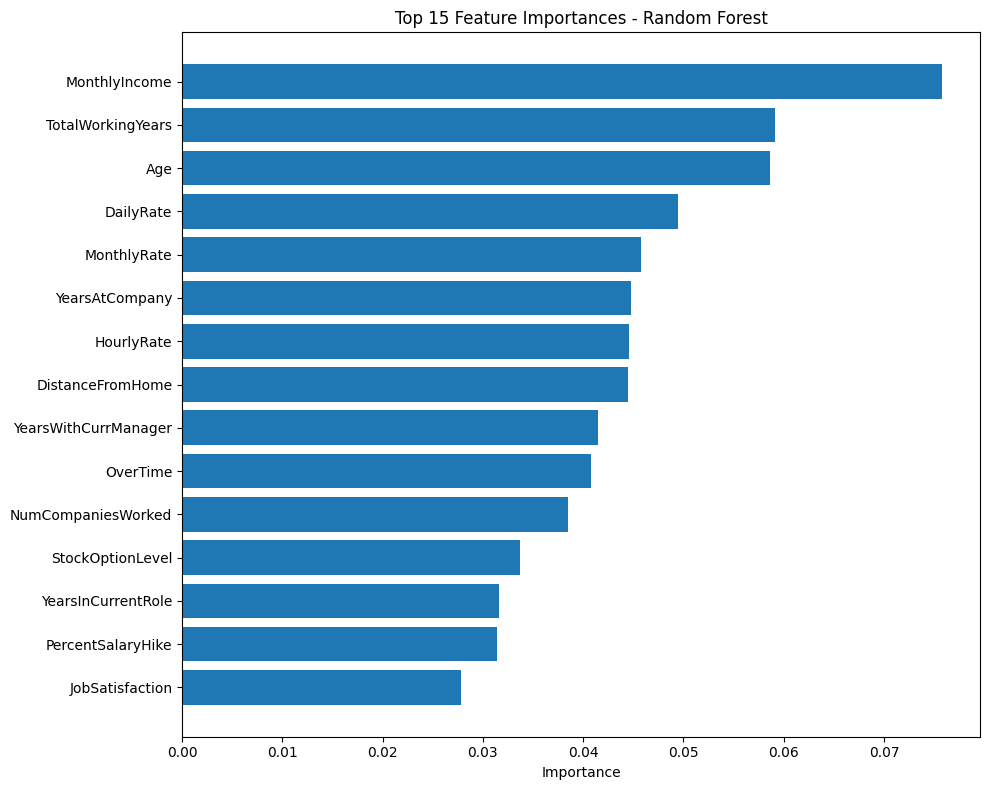

In [45]:
plt.figure(figsize=(10, 8))
top_features = feat_importance_df.head(15)
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [46]:
sample = x_test.iloc[[0]]
actual = y_test.iloc[0]

proba = rf_model2.predict_proba(sample)[:, 1][0]
prediction = "Yes" if proba >= 0.2 else "No"

print(f"احتمالية ترك الشركة: {proba:.2%}")
print(f"التوقع: {prediction}")
print(f"الحقيقة الفعلية: {'Yes' if actual == 1 else 'No'}")

احتمالية ترك الشركة: 60.50%
التوقع: Yes
الحقيقة الفعلية: No


In [47]:
sample_batch = x_test.iloc[:10]
actual_batch = y_test.iloc[:10]
proba_batch = rf_model2.predict_proba(sample_batch)[:, 1]
prediction_batch = ["Yes" if p >= 0.2 else "No" for p in proba_batch]
for i in range(10):
  actual = "Yes" if actual_batch.iloc[i] == 1 else "No"
  print(f"احتمالية ترك الشركة للنموذج {i+1}: {proba_batch[i]:.2%}")
  print(f"التوقع للنموذج {i+1}: {prediction_batch[i]}")

احتمالية ترك الشركة للنموذج 1: 60.50%
التوقع للنموذج 1: Yes
احتمالية ترك الشركة للنموذج 2: 5.50%
التوقع للنموذج 2: No
احتمالية ترك الشركة للنموذج 3: 11.50%
التوقع للنموذج 3: No
احتمالية ترك الشركة للنموذج 4: 2.00%
التوقع للنموذج 4: No
احتمالية ترك الشركة للنموذج 5: 26.50%
التوقع للنموذج 5: Yes
احتمالية ترك الشركة للنموذج 6: 11.50%
التوقع للنموذج 6: No
احتمالية ترك الشركة للنموذج 7: 8.00%
التوقع للنموذج 7: No
احتمالية ترك الشركة للنموذج 8: 7.00%
التوقع للنموذج 8: No
احتمالية ترك الشركة للنموذج 9: 2.00%
التوقع للنموذج 9: No
احتمالية ترك الشركة للنموذج 10: 44.00%
التوقع للنموذج 10: Yes


In [48]:
sample_batch = x_test.iloc[:10]
actual_batch = y_test.iloc[:10]

proba_batch = rf_model2.predict_proba(sample_batch)[:, 1]

correct = 0
for i in range(10):
    pred = "Yes" if proba_batch[i] >= 0.2 else "No"
    actual_label = "Yes" if actual_batch.iloc[i] == 1 else "No"
    match = "✅" if pred == actual_label else "❌"
    if pred == actual_label:
        correct += 1
    print(f"موظف {i}: احتمالية={proba_batch[i]:.1%} | التوقع={pred} | الفعلي={actual_label} {match}")

print(f"\nعدد التوقعات الصح: {correct}/10")

موظف 0: احتمالية=60.5% | التوقع=Yes | الفعلي=No ❌
موظف 1: احتمالية=5.5% | التوقع=No | الفعلي=No ✅
موظف 2: احتمالية=11.5% | التوقع=No | الفعلي=No ✅
موظف 3: احتمالية=2.0% | التوقع=No | الفعلي=No ✅
موظف 4: احتمالية=26.5% | التوقع=Yes | الفعلي=Yes ✅
موظف 5: احتمالية=11.5% | التوقع=No | الفعلي=No ✅
موظف 6: احتمالية=8.0% | التوقع=No | الفعلي=No ✅
موظف 7: احتمالية=7.0% | التوقع=No | الفعلي=No ✅
موظف 8: احتمالية=2.0% | التوقع=No | الفعلي=No ✅
موظف 9: احتمالية=44.0% | التوقع=Yes | الفعلي=No ❌

عدد التوقعات الصح: 8/10


In [49]:
!pip install xgboost --quiet

from xgboost import XGBClassifier


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(x_train, y_train)

y_pred_xgb = xgb_model.predict(x_test)

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

scale_pos_weight: 5.189473684210526
[[229  18]
 [ 31  16]]
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       247
           1       0.47      0.34      0.40        47

    accuracy                           0.83       294
   macro avg       0.68      0.63      0.65       294
weighted avg       0.82      0.83      0.82       294



In [50]:
y_proba_xgb = xgb_model.predict_proba(x_test)[:, 1]

for t in [ 0.3]:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_t))


Threshold = 0.3
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       247
           1       0.41      0.47      0.44        47

    accuracy                           0.81       294
   macro avg       0.65      0.67      0.66       294
weighted avg       0.82      0.81      0.81       294



In [51]:
import joblib

joblib.dump(rf_model2, 'attrition_model.pkl')
joblib.dump(x_train.columns.tolist(), 'model_columns.pkl')

from google.colab import files
files.download('attrition_model.pkl')
files.download('model_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>